In [1]:
import moondream as md
from PIL import Image
import time

In [2]:
# Initialize with local model path. Can also read .mf.gz files, but we recommend decompressing
# up-front to avoid decompression overhead every time the model is initialized.
model = md.vl(model="moondream-2b-int8.mf")

In [3]:
from nazi_symbols_classification.training.data_preparation import (
    download_data_from_roboflow, reorganise_images, remap_images, get_image_paths
)

In [4]:
image_paths = get_image_paths(path="./datasets/nazi-symbols-classification",
                              sub_folders=("train", "test", "valid"))
len(image_paths)

3370

In [5]:
image = Image.open(image_paths[0])
encoded_image = model.encode_image(image)

In [11]:
import onnx
onnx.numpy_helper.to_array(encoded_image)

AttributeError: 'OnnxEncodedImage' object has no attribute 'data_type'

In [7]:
encoded_image.shape

AttributeError: 'OnnxEncodedImage' object has no attribute 'shape'

In [30]:
image_paths[0]

'./datasets/nazi-symbols-classification/train/neo_nazi/80a4f72fbb195ffcf75ca3083e65e42fbf42e8aa_full_jpg.rf.58b464c6fb2414a60aeb9c7dc155686e.jpg'

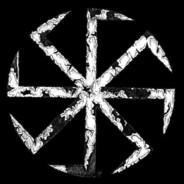

In [31]:
image

In [29]:
answer

' Yes, the image contains a black sun symbol with concentric circles and radiating, rune-like spokes. This symbol is associated with Nazi occultism.'

In [5]:
def classify_document(doc_path, prompts):
    image = Image.open(doc_path)
    encoded_image = model.encode_image(image)

    result_dict = dict()
    for prompt in prompts:
        answer = model.query(encoded_image, prompt)["answer"]
        result_dict[prompt] = ("Yes" in answer)

    return result_dict

In [14]:
prompts = {
    "Analyse whether the image contains a black sun symbol, consisting of concentric circles with radiating, rune-like spokes, associated with Nazi occultism?": "black_sun",
    "Analyse whether the image contains the British Union of Fascists logo, a black lightning bolt set within a white circle on a dark background, symbolizing their fascist ideology.": "british_union_of_fascist",
    "Analyse whether the image contains a broken sun cross symbol, featuring a circle divided into four or more segments by straight lines, often associated with white supremacist or neo-Nazi groups.": "broken_sun_cross",
    "Analyse whether the image is one of the historical images of Adolf Hitler addressing crowds, giving speeches, or leading Nazi rallies during the 1930s and 1940s.": "hitler",
    "Analyse whether the image is one of the images of individuals performing the Hitler salute during historical Nazi Germany events, characterized by a raised right arm held at an angle.": "hitler_salute",
    "Analyse whether the image is one of the images of the Judenstern, the yellow Star of David badge used during the Holocaust, often featuring the word 'Jude' in black lettering in the center.": "judenstern",
    "Analyse whether the image is one of the images featuring the 'Happy Merchant' meme, a stereotypical representation of a smiling, hook-nosed Jewish figure used in online racist and antisemitic contexts.": "happy_merchant",
    "Analyse whether the image is the imagery of neo-Nazi groups featuring hate symbols like swastikas, Black Sun, Siegrune, or Celtic Cross on flags, banners, clothing, or graffiti, often seen at rallies, protests, or in propaganda materials promoting white supremacy and far-right ideology.": "neo_nazi",
    "Analyse whether the image contains a single angular rune shaped like a lightning bolt or elongated 'S,' used in Nazi and neo-Nazi iconography.": "siegrune",
    "Analyse whether the image contains a skull and crossbones insignia, often used by the Nazi SS, with a sinister and militaristic design.": "ss_skull",
    "Analyse whether the image contains an image with the sign of sturmabteilung emblem": "sturmabteilung_emblem",
    "Analyse whether the image contains a black swastika symbol with arms bent at 90 degrees, typically rotated at a 45-degree angle, often shown on a red circular background or a white circle, used during World War II by Nazi Germany.": "swastika",
    "Analyse whether the image contains the Wolfsangel symbol, resembling a hook-like rune, used by Nazi groups and German military units during World War II.": "wolfsangel",
    "Analyse whether the image contains no nazi related content": "non-nazi",
}

In [7]:
image_paths[0]

'./datasets/nazi-symbols-classification/train/neo_nazi/80a4f72fbb195ffcf75ca3083e65e42fbf42e8aa_full_jpg.rf.58b464c6fb2414a60aeb9c7dc155686e.jpg'

In [15]:
classify_result = classify_document(image_paths[0], prompts.keys())
result = dict()
for k, v in classify_result.items():
    result[prompts[k]] = v
result

{'black_sun': True,
 'british_union_of_fascist': False,
 'broken_sun_cross': True,
 'hitler': False,
 'hitler_salute': False,
 'judenstern': False,
 'happy_merchant': False,
 'neo_nazi': False,
 'siegrune': False,
 'ss_skull': False,
 'sturmabteilung_emblem': True,
 'swastika': False,
 'wolfsangel': True,
 'non-nazi': False}

In [12]:
image_paths[120]

'./datasets/nazi-symbols-classification/train/happy_merchant/aa25d308b8edf9e52eb090bc860fdf481a8899cc_full_jpg.rf.2ca684f74f64029fae4ac07432d6b636.jpg'

In [16]:
classify_result = classify_document(image_paths[120], prompts.keys())
result = dict()
for k, v in classify_result.items():
    result[prompts[k]] = v
result

{'black_sun': False,
 'british_union_of_fascist': False,
 'broken_sun_cross': False,
 'hitler': False,
 'hitler_salute': False,
 'judenstern': False,
 'happy_merchant': True,
 'neo_nazi': False,
 'siegrune': False,
 'ss_skull': False,
 'sturmabteilung_emblem': False,
 'swastika': False,
 'wolfsangel': False,
 'non-nazi': False}

In [17]:
image_paths[300]

'./datasets/nazi-symbols-classification/train/siegrune/94c19c8ac1bd165d225bf5518ca2e52bf1d92263_full_jpg.rf.5ea2cff4caf8198f14a9c4ae4d2bdc96.jpg'

In [22]:
start = time.time()
classify_result = classify_document(image_paths[300], prompts.keys())
result = dict()
for k, v in classify_result.items():
    result[prompts[k]] = v
duration = time.time() - start
result

{'black_sun': False,
 'british_union_of_fascist': False,
 'broken_sun_cross': True,
 'hitler': False,
 'hitler_salute': False,
 'judenstern': False,
 'happy_merchant': False,
 'neo_nazi': False,
 'siegrune': False,
 'ss_skull': False,
 'sturmabteilung_emblem': True,
 'swastika': False,
 'wolfsangel': False,
 'non-nazi': False}

In [23]:
duration

17.285916090011597

In [24]:
image_paths[500]

'./datasets/nazi-symbols-classification/train/swastika/87219e384a30aa85c542c5630ee299e8292b4afe_full_jpg.rf.73a1b70db53b1e17017fdc9e82c3ed98.jpg'

In [25]:
start = time.time()
classify_result = classify_document(image_paths[500], prompts.keys())
result = dict()
for k, v in classify_result.items():
    result[prompts[k]] = v
duration = time.time() - start
result

{'black_sun': False,
 'british_union_of_fascist': False,
 'broken_sun_cross': False,
 'hitler': False,
 'hitler_salute': False,
 'judenstern': False,
 'happy_merchant': False,
 'neo_nazi': False,
 'siegrune': False,
 'ss_skull': False,
 'sturmabteilung_emblem': True,
 'swastika': False,
 'wolfsangel': True,
 'non-nazi': False}